In [1]:
from Bio.PDB import PDBParser
import numpy as np

def extract_plddt_multichain(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("prot", pdb_file)

    plddt = []
    chain_ids = []
    res_labels = []
    global_index = []

    idx = 0

    for model in structure:
        for chain in model:
            for res in chain:

                if res.id[0] != " ":
                    continue

                ca = res["CA"] if "CA" in res else None
                if ca is None:
                    continue

                plddt.append(ca.get_bfactor())
                chain_ids.append(chain.id)
                res_labels.append(res.id[1])
                global_index.append(idx)

                idx += 1

    return (
        np.array(plddt),
        np.array(chain_ids),
        np.array(res_labels),
        np.array(global_index)
    )

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

colors = [
    "red",          # 0–50
    "yellow",       # 50–70
    "deepskyblue",  # 70–90
    "blue"          # 90–100
]

bounds = [0, 50, 70, 90, 100]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

In [3]:
import csv
from pathlib import Path

def get_chain_breaks(chain_ids):
    breaks = []
    for i in range(1, len(chain_ids)):
        if chain_ids[i] != chain_ids[i-1]:
            breaks.append(i)
    return breaks

def load_chain_gene_map(chains_csv):
    """Load chains.csv and return a dict mapping Chain ID -> Gene name."""
    chain_gene = {}
    with open(chains_csv, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            chain_gene[row['Chain'].strip()] = row['Gene'].strip()
    return chain_gene


In [4]:
def plot_multichain_plddt(plddt, chain_ids, chain_gene_map=None, save_path=None):
    # Sort chains alphabetically
    unique_chains = sorted(set(chain_ids))
    order = np.concatenate([np.where(chain_ids == c)[0] for c in unique_chains])
    plddt = plddt[order]
    chain_ids = chain_ids[order]

    x = np.arange(len(plddt))

    fig, ax = plt.subplots(figsize=(12, 4))

    sc = ax.scatter(x, plddt, c=plddt, cmap=cmap, norm=norm, s=10)

    # chain 分割线
    breaks = get_chain_breaks(chain_ids)
    for b in breaks:
        ax.axvline(b, color="black", linewidth=0.8, alpha=0.5)

    # chain gene name annotations above the plot area
    if chain_gene_map is not None:
        boundaries = [0] + breaks + [len(chain_ids)]
        for i, chain in enumerate(unique_chains):
            mid = (boundaries[i] + boundaries[i + 1]) / 2
            label = chain_gene_map.get(chain, chain)
            ax.text(mid, 102, label, ha="center", va="bottom",
                    fontsize=8, clip_on=False)

    fig.colorbar(sc, ax=ax, label="pLDDT (ChimeraX-style)")
    ax.set_xlabel("Residue index (all chains concatenated)")
    ax.set_ylabel("pLDDT")
    # ax.set_title("Protein backbone (CA) confidence map")
    ax.set_xlim(0, len(plddt) - 1)
    ax.set_ylim(0, 100)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, format="svg", bbox_inches="tight")

    plt.show()


In [5]:
def plot_multichain_strip(plddt, chain_ids):
    plt.figure(figsize=(12, 2))

    plt.imshow(
        [plddt],
        cmap=cmap,
        norm=norm,
        aspect="auto"
    )

    breaks = get_chain_breaks(chain_ids)
    for b in breaks:
        plt.axvline(b, color="black", linewidth=1)

    plt.yticks([])
    plt.xlabel("Residue index (all chains concatenated)")
    plt.title("ChimeraX-style multichain pLDDT strip")
    plt.colorbar(label="pLDDT")

    plt.show()

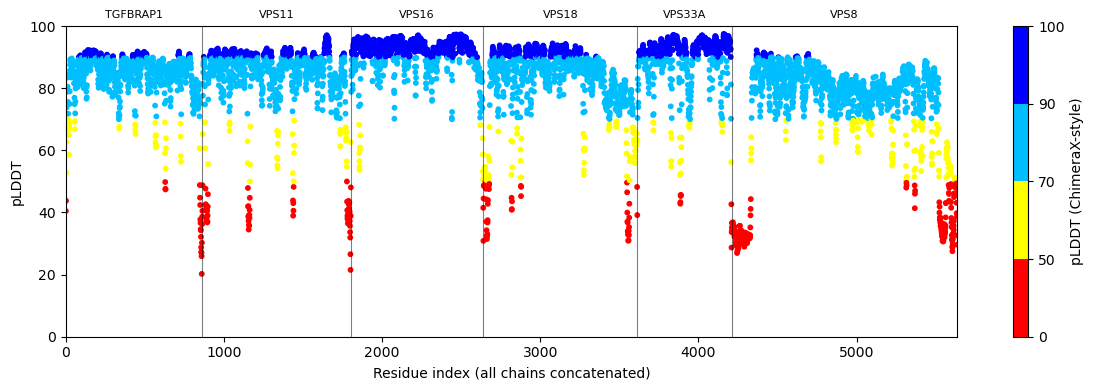

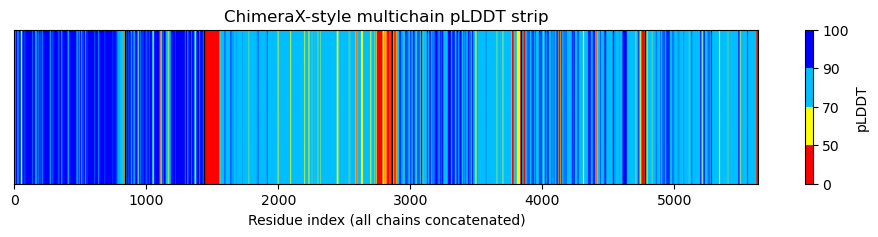

In [14]:
pdb_file = r"N:\08_NK_structure_prediction\XL_MOPLC\data\CORVET\assembled_complex\output\best_complex.pdb"
chains_csv = Path(pdb_file).parent.parent / "chains.csv"
chain_gene_map = load_chain_gene_map(chains_csv)

plddt, chain_ids, res_labels, idx = extract_plddt_multichain(pdb_file)

plot_multichain_plddt(plddt, chain_ids, chain_gene_map, save_path="CORVET_plddt.svg")
plot_multichain_strip(plddt, chain_ids)


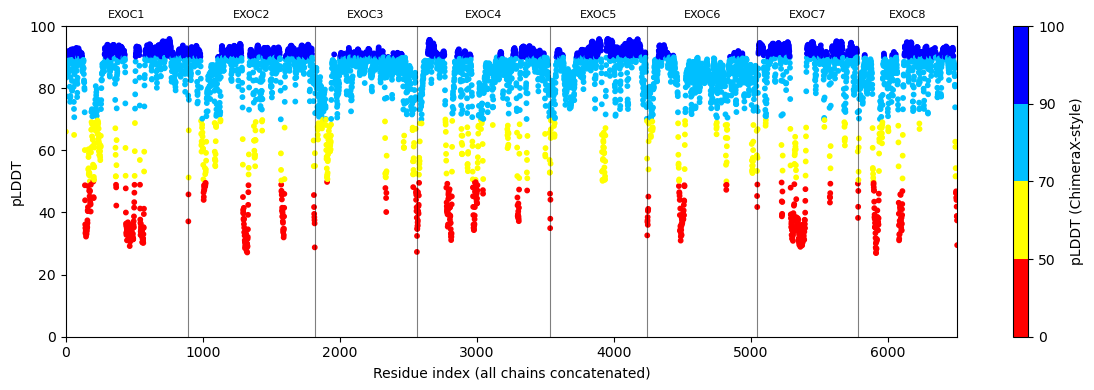

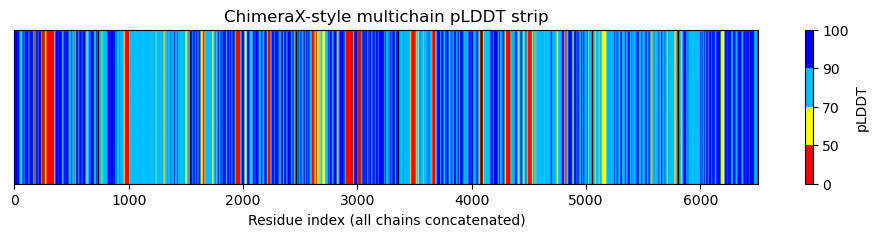

In [15]:
pdb_file = r"N:\08_NK_structure_prediction\data\Exocyst_complex\assembled_complex\output_all_inter_35a_better\best_complex.pdb"
chains_csv = Path(pdb_file).parent.parent / "chains.csv"
chain_gene_map = load_chain_gene_map(chains_csv)

plddt, chain_ids, res_labels, idx = extract_plddt_multichain(pdb_file)

plot_multichain_plddt(plddt, chain_ids, chain_gene_map, save_path="Exocyst_plddt.svg")
plot_multichain_strip(plddt, chain_ids)


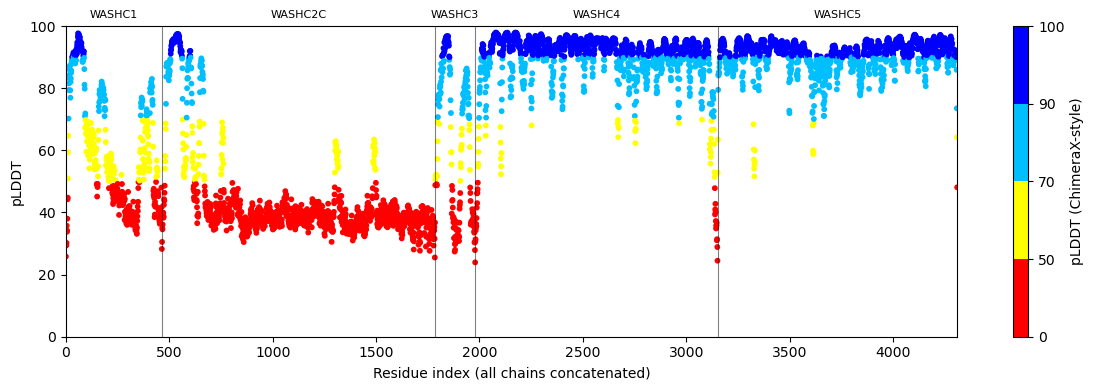

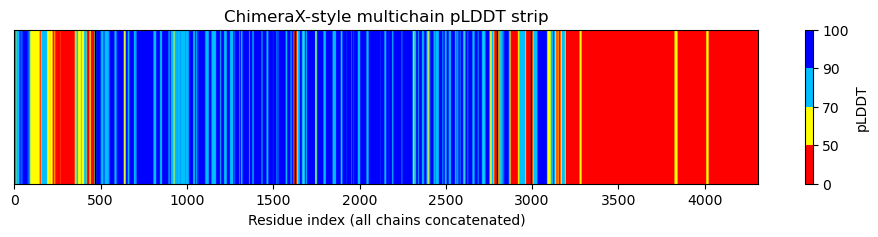

In [17]:
pdb_file = r"N:\08_NK_structure_prediction\data\WASH_complex\assembled_complex\output_interact_FKBP15_best\best_complex_core.pdb"
chains_csv = Path(pdb_file).parent.parent / "chains.csv"
chain_gene_map = load_chain_gene_map(chains_csv)

plddt, chain_ids, res_labels, idx = extract_plddt_multichain(pdb_file)

plot_multichain_plddt(plddt, chain_ids, chain_gene_map, save_path="WASH_core_plddt.svg")
plot_multichain_strip(plddt, chain_ids)


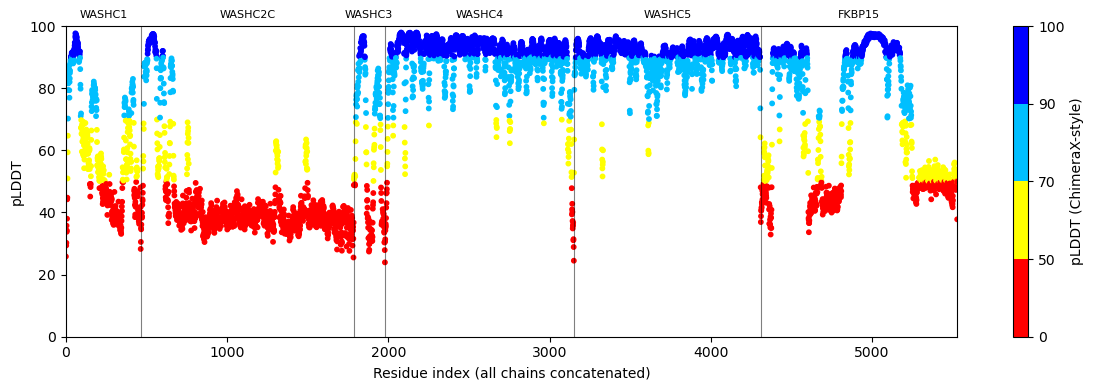

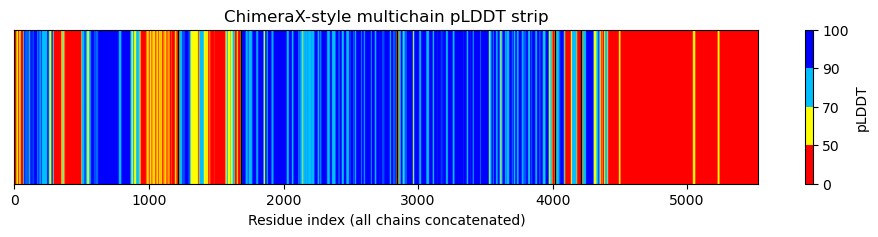

In [18]:
pdb_file = r"N:\08_NK_structure_prediction\data\WASH_complex\assembled_complex\output_interact_FKBP15_best\best_complex.pdb"
chains_csv = Path(pdb_file).parent.parent / "chains.csv"
chain_gene_map = load_chain_gene_map(chains_csv)

plddt, chain_ids, res_labels, idx = extract_plddt_multichain(pdb_file)

plot_multichain_plddt(plddt, chain_ids, chain_gene_map, save_path="WASH_plddt.svg")
plot_multichain_strip(plddt, chain_ids)


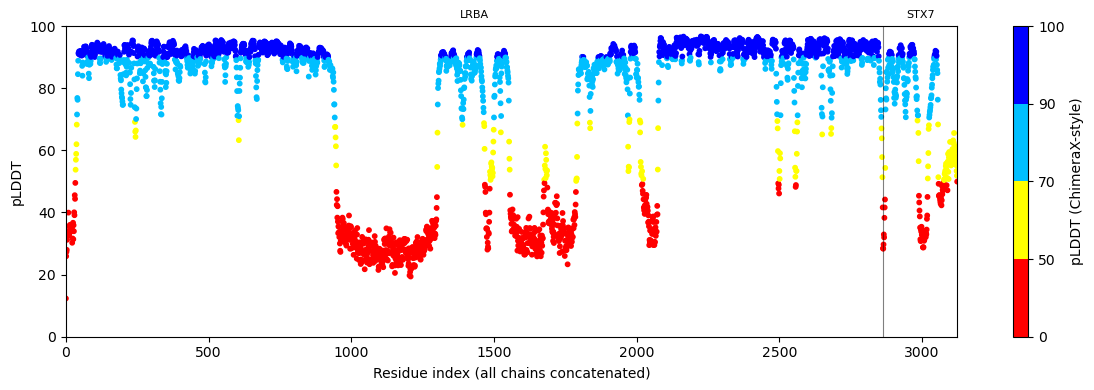

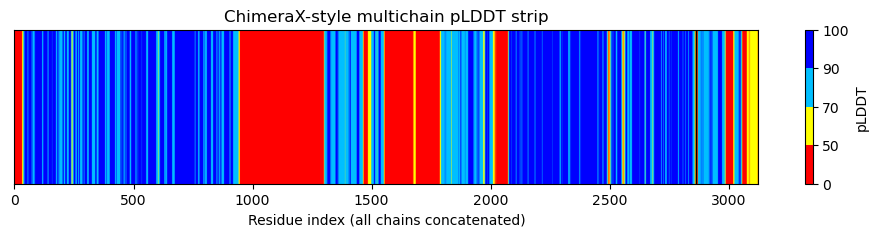

In [6]:
pdb_file = r"N:\08_NK_structure_prediction\data\LRBAandSNARE\assembled_complex\output\lrba_stx7_complete.pdb"
chains_csv = r"N:\08_NK_structure_prediction\data\LRBAandSNARE\chains.csv"
chain_gene_map = load_chain_gene_map(chains_csv)

plddt, chain_ids, res_labels, idx = extract_plddt_multichain(pdb_file)

plot_multichain_plddt(plddt, chain_ids, chain_gene_map, save_path="lrba_stx7_plddt.svg")
plot_multichain_strip(plddt, chain_ids)


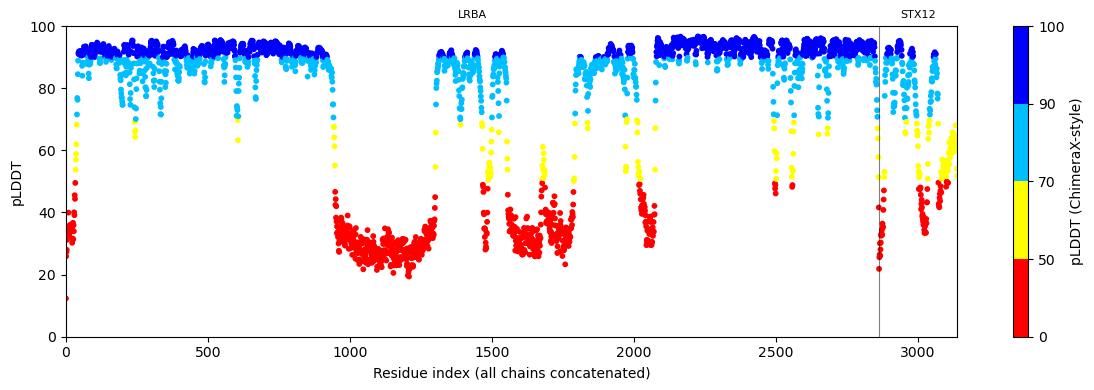

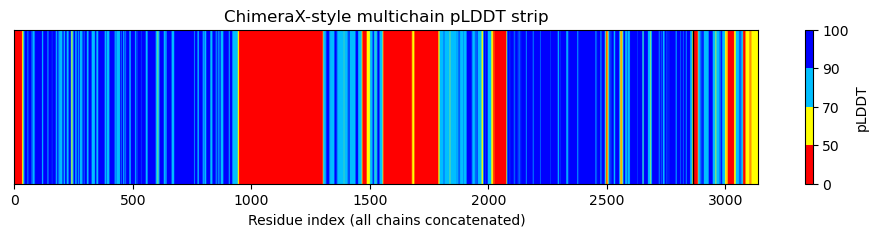

In [7]:
pdb_file = r"N:\08_NK_structure_prediction\data\LRBAandSNARE\assembled_complex\output\lrba_stx12_complete.pdb"
chains_csv = r"N:\08_NK_structure_prediction\data\LRBAandSNARE\chains.csv"
chain_gene_map = load_chain_gene_map(chains_csv)

plddt, chain_ids, res_labels, idx = extract_plddt_multichain(pdb_file)

plot_multichain_plddt(plddt, chain_ids, chain_gene_map, save_path="lrba_stx12_plddt.svg")
plot_multichain_strip(plddt, chain_ids)
